# Main analyses MPM Borderline

## Load prerequisites

In [ ]:
# housekeeping
import numpy as np
import pandas as pd
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import reduce_by_labels, map_to_labels
from brainstat.datasets import fetch_parcellation
from brainstat.datasets import fetch_yeo_networks_metadata
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
from matplotlib import pyplot as plt
from scipy.stats import spearmanr
import seaborn as sbn

pth = './outputs/equivols'
opth = './scripts/analyses'

smooth = True

In [2]:
demo = pd.read_csv(f'{opth}/demodata_short.csv')

mt1_df = pd.read_csv(f'{pth}/mt_moment1.csv')
mt2_df = pd.read_csv(f'{pth}/mt_moment2.csv')
mt3_df = pd.read_csv(f'{pth}/mt_moment3.csv')
r2s1_df = pd.read_csv(f'{pth}/r2_moment1.csv')
r2s2_df = pd.read_csv(f'{pth}/r2_moment2.csv')
r2s3_df = pd.read_csv(f'{pth}/r2_moment3.csv')

# for plotting
surf_lh, surf_rh = load_fsa5()
parc = fetch_parcellation(template = 'fsaverage5', atlas = 'schaefer', n_regions = 400, join = True)

In [3]:
# filter - only subjects with valid clinical data
subjs_demo = np.array([item.replace('sub-', '') for item in demo['ID']], dtype = 'f')
demo['ID_new'] = np.array([item.replace('sub-', '') for item in demo['ID']], dtype = 'f')

mt1_data = mt1_df[mt1_df['0'].isin(subjs_demo)].copy()
mt2_data = mt2_df[mt2_df['0'].isin(subjs_demo)].copy()
mt3_data = mt3_df[mt3_df['0'].isin(subjs_demo)].copy()
r2s1_data = r2s1_df[r2s1_df['0'].isin(subjs_demo)].copy()
r2s2_data = r2s2_df[r2s2_df['0'].isin(subjs_demo)].copy()
r2s3_data = r2s3_df[r2s3_df['0'].isin(subjs_demo)].copy()

In [4]:
def exclude_outliers(data_in):
    data_out = data_in.copy()
    data_cols = data_out.columns[2:]
    #rowwise_mean = data_out[data_cols].mean(axis = 1)
    #rowwise_std = data_out[data_cols].std(axis = 1)
    #mask = data_out[data_cols].lt((rowwise_mean -3*rowwise_std), axis = 1) | data_out[data_cols].gt((rowwise_mean +3*rowwise_std), axis = 1)
    values = data_in[data_cols]
    global_mean = values.to_numpy().mean()
    global_std = values.to_numpy().std()

    upper = global_mean+3*global_std
    lower = global_mean-3*global_std
    
    data_out.loc[:, data_cols] = values.clip(lower = lower, upper = upper)
    #data_out.loc[:, data_cols] = data_out[data_cols].mask(mask).copy()
    print(np.unique(((values<(global_mean-3*global_std)) | (values>(global_mean+3*global_std))),return_counts = True))
    return data_out

excl = True
if excl:
    mt1_data = exclude_outliers(mt1_data)
    mt2_data = exclude_outliers(mt2_data)
    mt3_data = exclude_outliers(mt3_data)
    r2s1_data = exclude_outliers(r2s1_data)
    r2s2_data = exclude_outliers(r2s2_data)
    r2s3_data = exclude_outliers(r2s3_data)

(array([False,  True]), array([2866546,  165086]))
(array([False,  True]), array([3028574,    3058]))


/tmp/ipykernel_317461/2599131084.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out.loc[:, data_cols] = values.clip(lower = lower, upper = upper)
/tmp/ipykernel_317461/2599131084.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out.loc[:, data_cols] = values.clip(lower = lower, upper = upper)


(array([False]), array([3031632]))
(array([False,  True]), array([2883520,  148112]))
(array([False,  True]), array([2990693,   40939]))


/tmp/ipykernel_317461/2599131084.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out.loc[:, data_cols] = values.clip(lower = lower, upper = upper)
/tmp/ipykernel_317461/2599131084.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out.loc[:, data_cols] = values.clip(lower = lower, upper = upper)


(array([False]), array([3031632]))


In [5]:
# plot main
def plot_mean(plot_data, labeltext, cmin, cmax):
    mean_plotdata = np.nanmean(np.array(plot_data)[:, 2:], axis = 0)
    mean_plotdata[parc == 0]=np.nan

    p = plot_hemispheres(surf_lh, surf_rh, mean_plotdata,
                     embed_nb = True, size = (1200, 300), nan_color = (.7, .7, .7, 1), 
                     zoom = 1.2, color_bar = True, color_range = (cmin, cmax),
                     label_text = [labeltext])

    with open(f"{opth}/mean_{labeltext}{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(p.data)

    return p

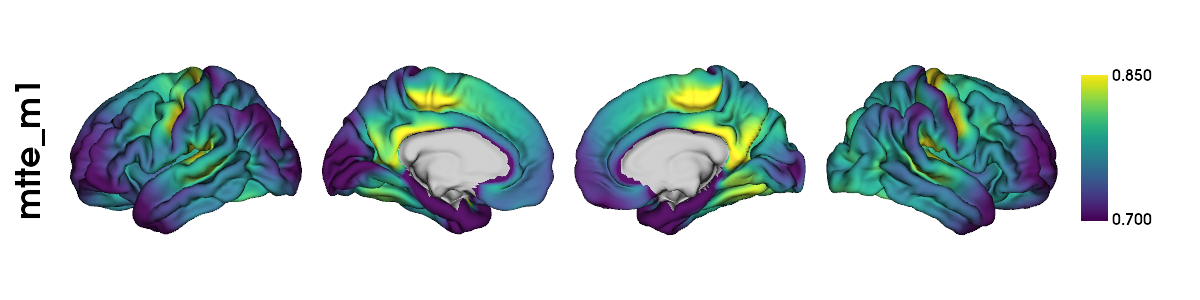

In [34]:
plot_mean(mt1_data, 'mtte_m1', 0.7, 0.85)

## Aim 1: BPD vs CRC

### BPD vs CRC

In [35]:
def bpd_vs_crc(allsubjects_data, name):
    """
    Tests BPD vs CRC group differences and age differences
    define as function to easier run on different data
    """
    demo_bpd_crc = demo[demo['Referral_Diagnosis'].isin([1,3])]
    demo_bpd_crc['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
    demo_bpd_crc['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    
    data_bpd_crc = allsubjects_data[allsubjects_data['0'].isin(demo_bpd_crc['ID_new'])].copy()
    
    term_age = FixedEffect(demo_bpd_crc.Age)
    term_sex = FixedEffect(demo_bpd_crc.Gender) # note: gender ~ sex in data collection
    term_diagnosis = FixedEffect(demo_bpd_crc.Referral_Diagnosis)
    
    contrast_group = (demo_bpd_crc.Referral_Diagnosis == 'BPD').astype(int) - (demo_bpd_crc.Referral_Diagnosis == 'CRC').astype(int)
    contrast_age = demo_bpd_crc.Age
    
    model = term_age + term_sex + term_diagnosis

    slm_group = SLM(model, contrast_group, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_group.fit(np.array(data_bpd_crc)[:, 2:])

    p_group = slm_group.P['pval']['C']
    print(np.unique(p_group)) # sanity check
    p_group[(parc == 0) | (p_group>0.05)] = np.nan

    bpd_idx = model.matrix.columns.get_loc('Referral_Diagnosis_BPD') 
    crc_idx = model.matrix.columns.get_loc('Referral_Diagnosis_CRC') 
    beta = np.array(slm_group.coef)[bpd_idx, :] - np.array(slm_group.coef)[crc_idx, :]

    array_plot_group = np.vstack((slm_group.t, beta, p_group))
    plot_group = plot_hemispheres(surf_lh, surf_rh, array_plot_group, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t group', 'b group', 'p group'])

    with open(f"{opth}/{name}_group_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_group.data)

    pd.DataFrame({'t': np.array(slm_group.t)[0], 
                  'b': beta,
                  'p': np.array(slm_group.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_group_{name}{'_sm5' if smooth else ''}.csv")

    slm_age = SLM(model, contrast_age, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_age.fit(np.array(data_bpd_crc)[:, 2:])

    p_age = slm_age.P['pval']['C'].copy()
    print(np.unique(p_age))
    p_age[(parc == 0) | (p_age>0.05)] = np.nan

    array_plot_age = np.vstack((slm_age.t, slm_age.coef[1], p_age))
    plot_age = plot_hemispheres(surf_lh, surf_rh, array_plot_age, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t age', 'b age', 'p age'])

    with open(f"{opth}/{name}_age_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_age.data)

    pd.DataFrame({'t': np.array(slm_age.t)[0], 
                  'b': np.array(slm_age.coef)[1,:],
                  'p': np.array(slm_age.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_age_{name}{'_excl' if excl else ''}{'_sm5' if smooth else ''}.csv")

    return slm_group, slm_age, plot_group, plot_age

/tmp/ipykernel_317461/3300097163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
/tmp/ipykernel_317461/3300097163.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Gender'].replace({1:'M', 2:'F'}, inplace = True)


[0.0653039  0.47989437 0.86184832 0.94971266 1.        ]
[1.]


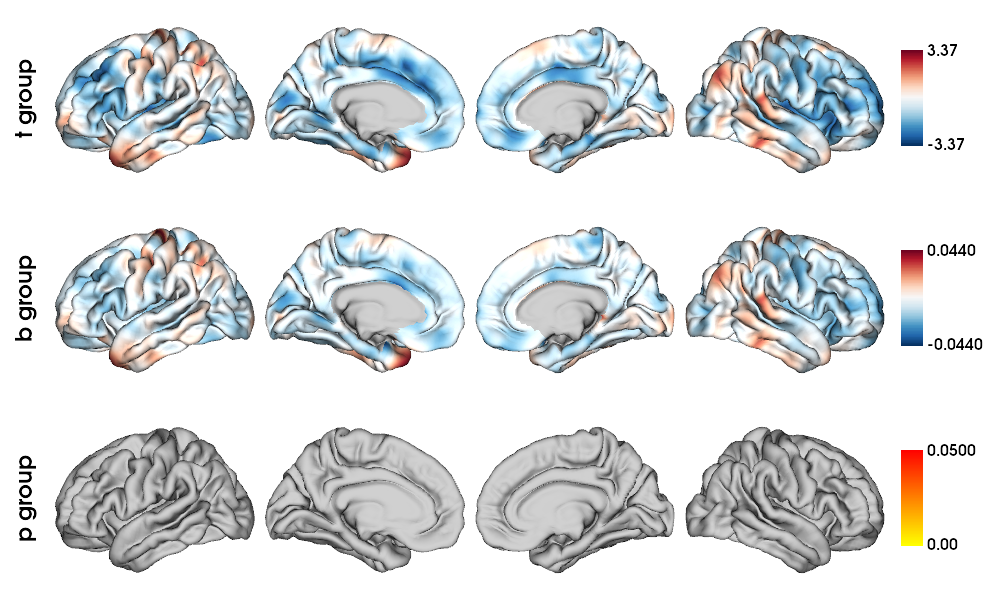

In [39]:
bpd_vs_crc(mt1_data, 'mt_m1')[2]

### p-factor

In [40]:
demo_hitop = pd.read_csv(f'{opth}/demodata_hitop.csv')

In [41]:
def pfactor_slm(allsubjects_data, name):
    """
    Tests HiTOP p-factor influences
    define as function to easier run on different data
    """
    demo_hitop['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    
    term_age = FixedEffect(demo_hitop.Age)
    term_sex = FixedEffect(demo_hitop.Gender) # note: gender ~ sex in data collection
    term_p_HiTOP = FixedEffect(demo_hitop.p_HiTOP)
    
    contrast_p = demo_hitop.p_HiTOP
    contrast_age = demo_hitop.Age
    
    model = term_age + term_sex + term_p_HiTOP

    slm_p = SLM(model, contrast_p, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_p.fit(np.array(allsubjects_data)[:, 2:])

    p_p = slm_p.P['pval']['C']
    print(np.unique(p_p)) # sanity check
    p_p[(parc == 0) | (p_p>0.05)] = np.nan

    array_plot_p = np.vstack((slm_p.t, slm_p.coef[4], p_p))
    plot_p = plot_hemispheres(surf_lh, surf_rh, array_plot_p, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t group', 'b group', 'p group'])

    with open(f"{opth}/{name}_p_HiTOP_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_p.data)

    pd.DataFrame({'t': np.array(slm_p.t)[0], 
                  'b': np.array(slm_p.coef)[4,:],
                  'p': np.array(slm_p.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_p_HiTOP_{name}{'_sm5' if smooth else ''}.csv")

    return slm_p, plot_p

[1.]


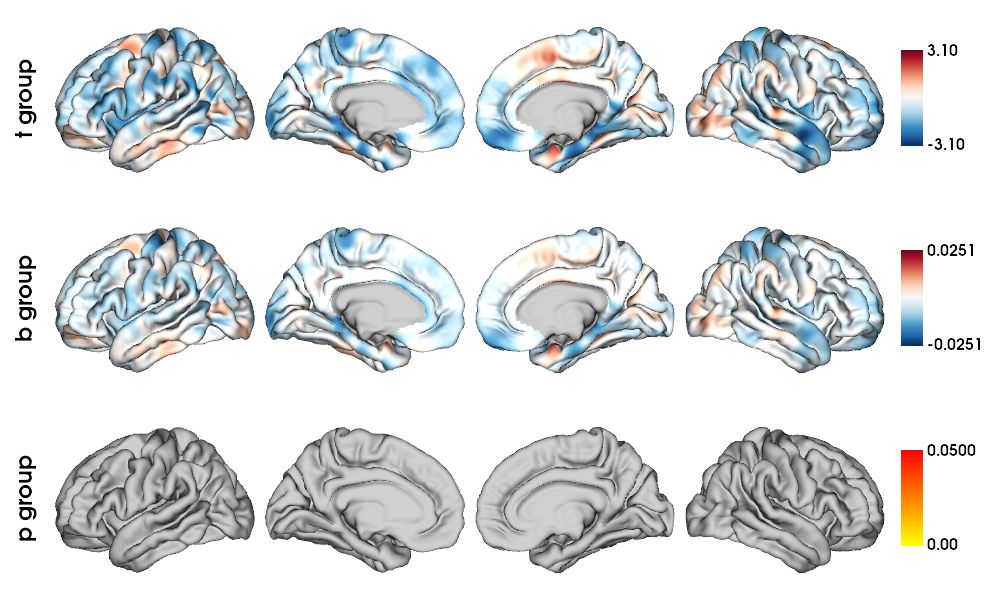

In [45]:
pfactor_slm(mt1_data, 'mt_m1')[1]

#### in BPD and CRC only

In [46]:
# repeat analysis only in CRC and BPD individuals
def pfactor_slm_bpdcrc(data, name):
    """
    Tests HiTOP p-factor influences
    define as function to easier run on different data
    """
    demo_hitop_bpdcrc = demo_hitop[demo_hitop['Referral_Diagnosis'].isin([1,3])]
    allsubjects_data = data[data['0'].isin(demo[demo['Referral_Diagnosis'].isin([1,3])]['ID_new'].values).copy()]
    print(demo_hitop_bpdcrc.shape, allsubjects_data.shape)
    demo_hitop_bpdcrc['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    
    term_age = FixedEffect(demo_hitop_bpdcrc.Age)
    term_sex = FixedEffect(demo_hitop_bpdcrc.Gender) # note: gender ~ sex in data collection
    term_p_HiTOP = FixedEffect(demo_hitop_bpdcrc.p_HiTOP)
    
    contrast_p = demo_hitop_bpdcrc.p_HiTOP
    contrast_age = demo_hitop_bpdcrc.Age
    
    model = term_age + term_sex + term_p_HiTOP

    slm_p = SLM(model, contrast_p, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_p.fit(np.array(allsubjects_data)[:, 2:])

    p_p = slm_p.P['pval']['C']
    print(np.unique(p_p)) # sanity check
    p_p[(parc == 0) | (p_p>0.05)] = np.nan

    array_plot_p = np.vstack((slm_p.t, slm_p.coef[4], p_p))
    plot_p = plot_hemispheres(surf_lh, surf_rh, array_plot_p, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t group', 'b group', 'p group'])

    with open(f"{opth}/{name}_p_HiTOP_CRC-BPD_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_p.data)

    pd.DataFrame({'t': np.array(slm_p.t)[0], 
                  'b': np.array(slm_p.coef)[4,:],
                  'p': np.array(slm_p.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_p_HiTOP_CRC-BPD_{name}{'_sm5' if smooth else ''}.csv")

    return slm_p, plot_p

(128, 156) (128, 20486)


/tmp/ipykernel_317461/1473609914.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_hitop_bpdcrc['Gender'].replace({1:'M', 2:'F'}, inplace = True)


[0.28837404 1.        ]


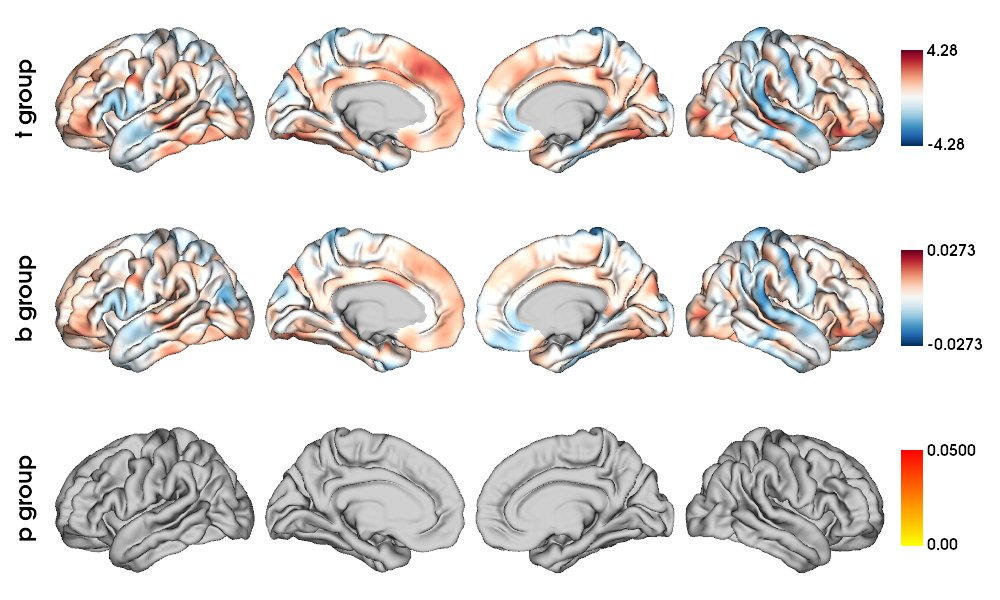

In [50]:
pfactor_slm_bpdcrc(mt1_data, 'mt_m1')[1]

## Aim 2: Adversity effects
### CTQ

In [51]:
def ctq_effect(allsubjects_data, name):
    """
    Tests CTQ effect
    define as function to easier run on different data
    """
    demo_ctq = demo[demo['CTQ_sum'] < 126].copy() # missing data is implausible value above cutoff 125
    demo_ctq['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    
    data_ctq = allsubjects_data[allsubjects_data['0'].isin(demo_ctq['ID_new'])].copy()
    
    term_age = FixedEffect(demo_ctq.Age)
    term_sex = FixedEffect(demo_ctq.Gender) # note: gender ~ sex in data collection
    term_ctq = FixedEffect(demo_ctq.CTQ_sum)
    
    contrast_ctq = demo_ctq.CTQ_sum
    
    model_ctq = term_age + term_sex + term_ctq

    slm_ctq = SLM(model_ctq, contrast_ctq, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_ctq.fit(np.array(data_ctq)[:, 2:])

    p_ctq = slm_ctq.P['pval']['C']
    print(np.unique(p_ctq))
    p_ctq[(p_ctq >0.05) | (parc == 0)] = np.nan

    array_plot_ctq = np.vstack((slm_ctq.t, slm_ctq.coef[4], p_ctq))
    plot_ctq = plot_hemispheres(surf_lh, surf_rh, array_plot_ctq, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r','RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t CTQ', 'beta CTQ', 'p CTQ'])

    with open(f"{opth}/figs/{name}_ctq_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_ctq.data)

    pd.DataFrame({'t': np.array(slm_ctq.t)[0], 
                  'b': np.array(slm_ctq.coef)[4,:],
                  'p': np.array(slm_ctq.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_ctq_{name}{'_excl' if excl else ''}{'_sm5' if smooth else ''}.csv")

    print(data_ctq.shape[0], 'cases included')
    return slm_ctq, plot_ctq

[0.13604463 1.        ]
144 cases included


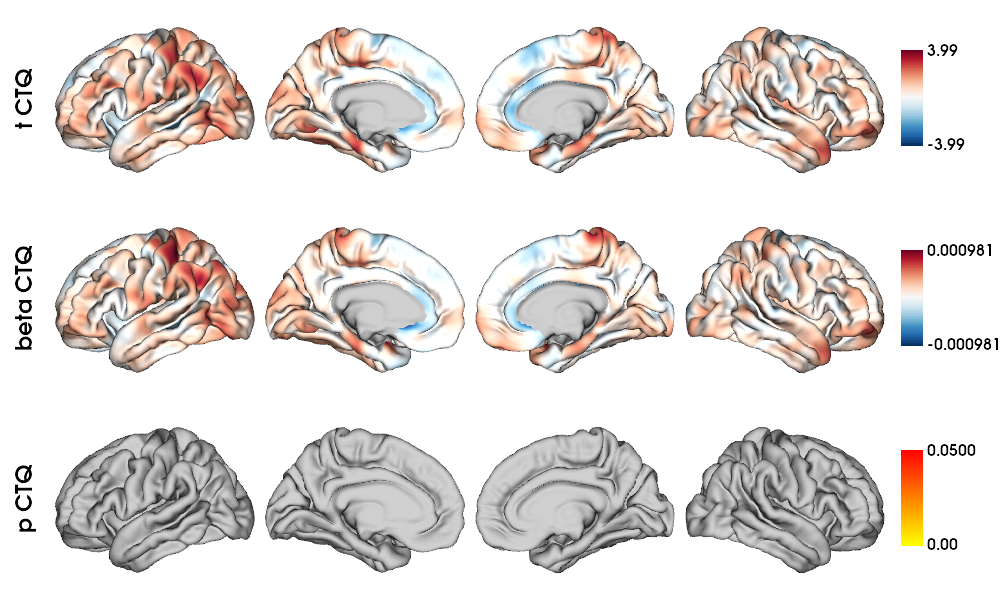

In [55]:
ctq_effect(mt1_data, 'mt_m1')[1]

### SDI

In [56]:
def sdi_effect(allsubjects_data, name):
    """
    Tests SDI effect
    define as function to easier run on different data
    """
    demo_sdi = demo[demo['SocialDeprivationIndex'] < 9000].copy() # missing data is implausible value 
    demo_sdi['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    
    data_sdi = allsubjects_data[allsubjects_data['0'].isin(demo_sdi['ID_new'])].copy()
    
    term_age = FixedEffect(demo_sdi.Age)
    term_sex = FixedEffect(demo_sdi.Gender) # note: gender ~ sex in data collection
    term_sdi = FixedEffect(demo_sdi.SocialDeprivationIndex)
    
    contrast_sdi = demo_sdi.SocialDeprivationIndex
    
    model_sdi = term_age + term_sex + term_sdi

    slm_sdi = SLM(model_sdi, contrast_sdi, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_sdi.fit(np.array(data_sdi)[:, 2:])

    p_sdi = slm_sdi.P['pval']['C']
    print(np.unique(p_sdi))
    p_sdi[(parc == 0) | (p_sdi >0.05)] = np.nan

    array_plot_sdi = np.vstack((slm_sdi.t, slm_sdi.coef[4], p_sdi))
    plot_sdi = plot_hemispheres(surf_lh, surf_rh, array_plot_sdi, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t SDI', 'beta SDI', 'p SDI'])

    with open(f"{opth}/figs/{name}_sdi_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_sdi.data)
    
    pd.DataFrame({'t': np.array(slm_sdi.t)[0], 
                  'b': np.array(slm_sdi.coef)[4,:],
                  'p': np.array(slm_sdi.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_sdi_{name}{'_excl' if excl else ''}{'_sm5' if smooth else ''}.csv")

    print(data_sdi.shape[0], 'cases included')
    return slm_sdi, plot_sdi

[0.27573456 0.43921989 0.44444237 0.79025184 1.        ]
128 cases included


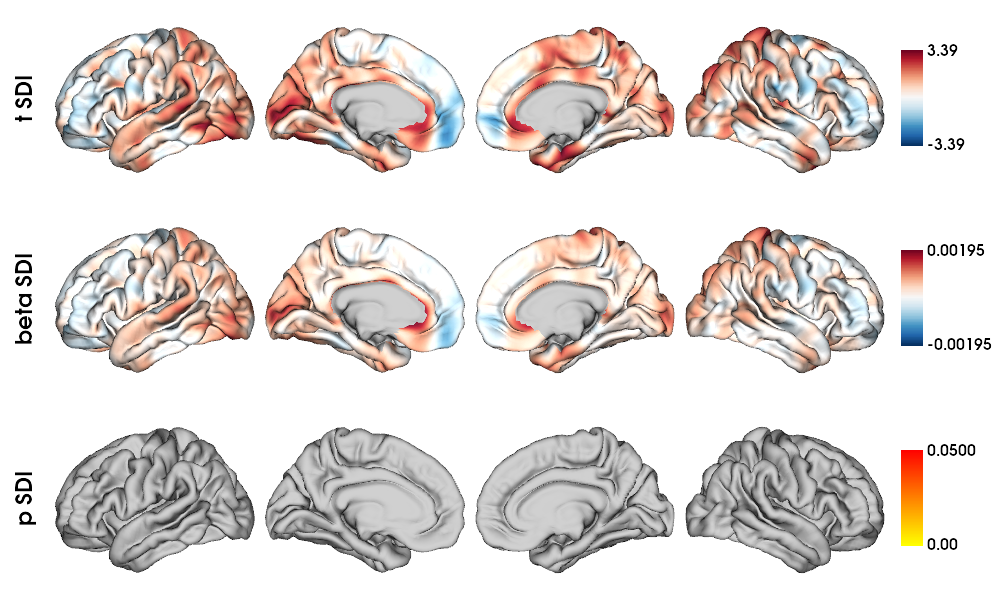

In [60]:
sdi_effect(mt1_data, 'mt_m1')[1]

## Aim 3: Contextualization of maps

### Yeo networks

In [61]:
yeo7 = fetch_parcellation(template = 'fsaverage5', atlas = 'yeo', n_regions = 7)
yeo7names, yeo7colors = fetch_yeo_networks_metadata(7)

In [62]:
def cohensd(data_bpd, data_crc):
    nbpd = len(data_bpd)
    ncrc = len(data_crc)
    dof = nbpd + ncrc -2
    return (np.mean(data_bpd) - np.mean(data_crc))/np.sqrt(((nbpd-1)*np.std(data_bpd, ddof = 1)**2 +(ncrc-1)*np.std(data_crc, ddof = 1)**2)/ dof)

In [63]:
def plot_innetworks(allsubjects_data, name):
    demo_bpd = demo[demo['Referral_Diagnosis'] == 1]
    data_bpd = allsubjects_data[allsubjects_data['0'].isin(demo_bpd['ID_new'])].copy()
    mean_bpd = np.mean(np.array(data_bpd)[:, 2:], axis = 0)
    
    demo_crc = demo[demo['Referral_Diagnosis'] == 3]
    data_crc = allsubjects_data[allsubjects_data['0'].isin(demo_crc['ID_new'])].copy()
    mean_crc = np.mean(np.array(data_crc)[:, 2:], axis = 0)
    
    df_plot = pd.DataFrame({
        'BPD' : mean_bpd[yeo7!=0],
        'CRC' : mean_crc[yeo7!=0],
        'yeo' : yeo7[yeo7!=0]
    }).melt(id_vars = 'yeo', value_vars = ['BPD', 'CRC'])

    cohensds = []
    for n in range(7):
        cohensds.append(cohensd(mean_bpd[yeo7==n+1], mean_crc[yeo7==n+1]))
    df_d  = pd.DataFrame({
        'yeo': range(1,8),
        'd': cohensds})

    sbn.set_style('white')
    fig, ax = plt.subplots(2, 1, figsize = (5,4), sharex = True)
    sbn.barplot(df_d, x = 'yeo', y = 'd', hue = 'yeo', palette = yeo7colors, ax = ax[0], legend = False)
    sbn.violinplot(df_plot, x = 'yeo', y = 'value', hue = 'variable', split = True, color = 'black', 
                   inner = 'quart', alpha = 1, gap = 0.1, cut = True, palette = ['#7265a6', 'lightgrey'], legend = False,
                  ax = ax[1])
    
    ax[1].set_xticklabels(yeo7names)
    ax[1].tick_params(labelrotation = 90)
    ax[0].set_title(name)

    fig.savefig(f"{opth}/figs/yeodistribution_{name}{'_excl' if excl else ''}{'_sm5' if smooth else ''}.svg", bbox_inches = 'tight')

/tmp/ipykernel_317461/1490395218.py:25: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sbn.barplot(df_d, x = 'yeo', y = 'd', hue = 'yeo', palette = yeo7colors, ax = ax[0], legend = False)
/tmp/ipykernel_317461/1490395218.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(yeo7names)


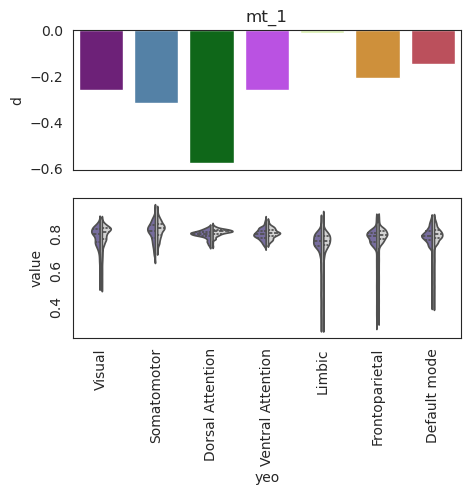

In [67]:
plot_innetworks(mt1_data, 'mt_1')

In [68]:
def plot_profiles_yeo(name):
    demo_bpd = demo[demo['Referral_Diagnosis'] == 1]
    demo_crc = demo[demo['Referral_Diagnosis'] == 3]

    depthvals_bpd = []
    depthvals_crc = []

    for d in range(1, 13):
        data_depth = pd.read_csv(f'{pth}/{name}_depth{d}.csv')
        data_crc = np.array(data_depth[data_depth['0'].isin(demo_crc['ID_new'])])[:, 2:]
        data_bpd = np.array(data_depth[data_depth['0'].isin(demo_bpd['ID_new'])])[:, 2:]
        depth_crc = []
        depth_bpd = []
        for y in range(1,8):
            depth_crc.append(np.mean(data_crc[:, yeo7 == y]))
            depth_bpd.append(np.mean(data_bpd[:, yeo7 == y]))
        depthvals_bpd.append(depth_bpd)
        depthvals_crc.append(depth_crc)
    
    df_plot_bpd = pd.DataFrame(depthvals_bpd, columns = yeo7names)
    df_plot_crc = pd.DataFrame(depthvals_crc, columns = yeo7names)

    fig, ax = plt.subplots(7, 1, figsize = (4, 10), sharex = True, sharey = True)
    for i in range(7):
        sbn.regplot(y = df_plot_bpd[yeo7names[i]].values, x = np.linspace(0,12,12), ax = ax[i], color = 'black', order = 3) 
        sbn.regplot(y = df_plot_crc[yeo7names[i]].values, x = np.linspace(0,12,12), ax = ax[i], color = yeo7colors[i], order = 3, 
                   line_kws = ({'alpha':0.7}))
    fig.savefig(f"{opth}/figs/yeoprofiles_{name}{'_sm5' if smooth else ''}.svg")

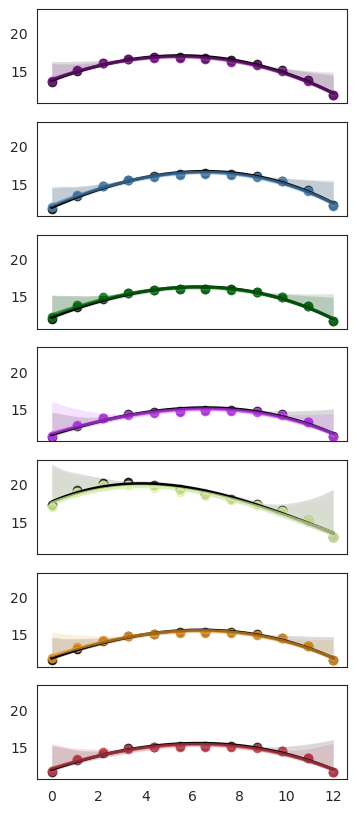

In [72]:
plot_profiles_yeo('r2')

### Cortical types

In [73]:
# from the enigma toolbox (https://github.com/MICA-MNI/ENIGMA/blob/master/enigmatoolbox/datasets/parcellations/economo_koskinas_fsa5.csv)
ek_fsa5 = pd.read_csv(f'{opth}/economo_koskinas_fsa5.csv', header = None)[0].values
eknames = ['Agranular', 'Frontal', 'Parietal', 'Polar', 'Granular']
ekcolors = ['purple', 'blue', 'green', 'orange', 'yellow']

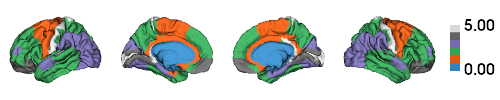

In [74]:
plot_hemispheres(surf_lh, surf_rh, ek_fsa5, embed_nb = True, size = (500,100), zoom = 1.2, color_bar = True, cmap = 'tab20c')

In [75]:
def plot_intypes(allsubjects_data, name):
    demo_bpd = demo[demo['Referral_Diagnosis'] == 1]
    data_bpd = allsubjects_data[allsubjects_data['0'].isin(demo_bpd['ID_new'])].copy()
    mean_bpd = np.mean(np.array(data_bpd)[:, 2:], axis = 0)
    
    demo_crc = demo[demo['Referral_Diagnosis'] == 3]
    data_crc = allsubjects_data[allsubjects_data['0'].isin(demo_crc['ID_new'])].copy()
    mean_crc = np.mean(np.array(data_crc)[:, 2:], axis = 0)
    
    df_plot = pd.DataFrame({
        'BPD' : mean_bpd[ek_fsa5!=0],
        'CRC' : mean_crc[ek_fsa5!=0],
        'ek' : ek_fsa5[ek_fsa5!=0]
    }).melt(id_vars = 'ek', value_vars = ['BPD', 'CRC'])

    cohensds = []
    for n in range(5):
        cohensds.append(cohensd(mean_bpd[ek_fsa5==n+1], mean_crc[ek_fsa5==n+1]))
    df_d  = pd.DataFrame({
        'ek': range(1,6),
        'd': cohensds})

    sbn.set_style('white')
    fig, ax = plt.subplots(2, 1, figsize = (5,4), sharex = True)
    sbn.barplot(df_d, x = 'ek', y = 'd', hue = 'ek', palette = ekcolors, ax = ax[0], legend = False)
    sbn.violinplot(df_plot, x = 'ek', y = 'value', hue = 'variable', split = True, color = 'black', 
                   inner = 'quart', alpha = 1, gap = 0.1, cut = True, palette = ['#7265a6', 'lightgrey'], legend = False,
                  ax = ax[1])
    
    ax[1].set_xticklabels(eknames)
    ax[1].tick_params(labelrotation = 90)
    ax[0].set_title(name)

    fig.savefig(f"{opth}/figs/ekdistribution_{name}{'_excl' if excl else ''}{'_sm5' if smooth else ''}.svg", bbox_inches = 'tight')

/tmp/ipykernel_317461/3060110036.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(eknames)


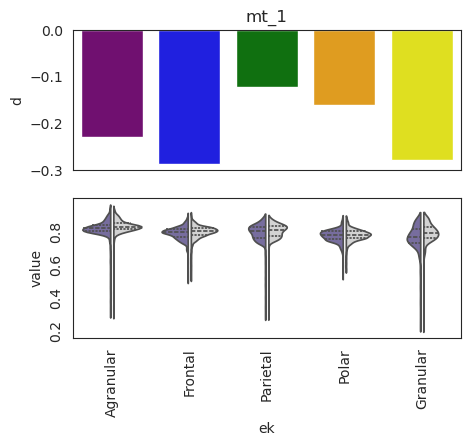

In [80]:
plot_intypes(mt1_data, 'mt_1')

### Genetic correlation

In [81]:
from enigmatoolbox.datasets import risk_genes
riskgenes_adhd = [*risk_genes('adhd')]
riskgenes_asd = [*risk_genes('asd')]
riskgenes_bp = [*risk_genes('bipolar')]
riskgenes_mdd = [*risk_genes('depression')]
riskgenes_scz = [*risk_genes('schizophrenia')]

genes_ahba = pd.read_csv(f'{opth}/allgenes_stable_r0.2_schaefer_400.csv')

In [82]:
# filter AHBA for GWAS-identified genes
exp_adhd = genes_ahba[[r for r in riskgenes_adhd if r in genes_ahba.columns]]
print(f'ADHD: of {len(riskgenes_adhd)}, in AHBA {exp_adhd.shape[1]}')
exp_asd = genes_ahba[[r for r in riskgenes_asd if r in genes_ahba.columns]]
print(f'ASD: of {len(riskgenes_asd)}, in AHBA {exp_asd.shape[1]}')
exp_bp = genes_ahba[[r for r in riskgenes_bp if r in genes_ahba.columns]]
print(f'Bipolar: of {len(riskgenes_bp)}, in AHBA {exp_bp.shape[1]}')
exp_mdd = genes_ahba[[r for r in riskgenes_mdd if r in genes_ahba.columns]]
print(f'MDD: of {len(riskgenes_mdd)}, in AHBA {exp_mdd.shape[1]}')
exp_scz = genes_ahba[[r for r in riskgenes_scz if r in genes_ahba.columns]]
print(f'Schizophrenia: of {len(riskgenes_scz)}, in AHBA {exp_scz.shape[1]}')

ADHD: of 26, in AHBA 12
ASD: of 30, in AHBA 14
Bipolar: of 30, in AHBA 26
MDD: of 269, in AHBA 131
Schizophrenia: of 213, in AHBA 86


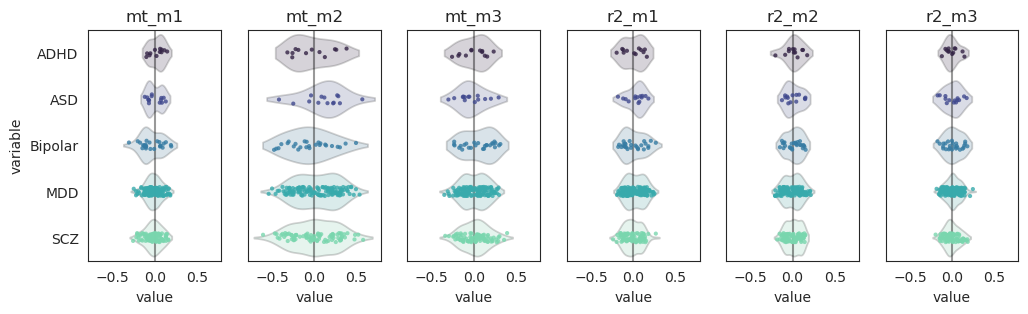

In [83]:
fig, ax = plt.subplots(1, 6, figsize = (12,3), sharey = True, sharex = True)
sbn.set_theme(font = 'Univers')
sbn.set_style('white')

for i, name in enumerate(['mt_m1', 'mt_m2', 'mt_m3', 'r2_m1', 'r2_m2', 'r2_m3']):
    ax[i].axvline(x = 0, color = 'black', alpha = 0.4)
    
    b_one = pd.read_csv(f"{opth}/results/stats_group_{name}{'_sm5' if smooth else ''}.csv")['b']
    b_s400 = reduce_by_labels(b_one, parc)[1:] # parcellate, remove midline
    
    tmp_plt = []
    
    conds = ['ADHD', 'ASD', 'Bipolar', 'MDD', 'SCZ']
    for e, exp in enumerate([exp_adhd, exp_asd, exp_bp, exp_mdd, exp_scz]):
        tmp_rs = []
        for g in exp.columns:
            onegene_data = exp[g].values[:400]
            onegene_mask = ~np.isnan(onegene_data)
            r, _ = spearmanr(b_s400[onegene_mask], onegene_data[onegene_mask])
            tmp_plt.append([conds[e], r])
    
    pltdf = pd.DataFrame(tmp_plt, columns = ['variable', 'value'])
    
    # plot
    sbn.stripplot(pltdf, x = 'value', y = 'variable', hue = 'variable', s = 3, alpha = 0.8, ax = ax[i], palette = 'mako')
    sbn.violinplot(pltdf, x = 'value', y = 'variable', hue = 'variable', split = False, 
                   color = None, fill = 'grey', alpha = 0.2, inner = None, cut = True, ax = ax[i], palette = 'mako')
    ax[i].set_title(name)

    fig.savefig(f"{opth}/figs/genetic_correlation_violins{'_sm5' if smooth else ''}.svg")

# Robustness analyses

## Main analyses at different cortical depths

In [84]:
for d in range(1,13):
    depth_mt_df = pd.read_csv(f'{pth}/mt_depth{d}.csv')
    if excl:
        depth_mt_df = exclude_outliers(depth_mt_df)

    bpd_vs_crc(depth_mt_df, f'mt_d{d}')
    #ctq_effect(depth_mt_df, f'mt_d{d}') 
    #sdi_effect(depth_mt_df, f'mt_d{d}')   

(array([False,  True]), array([3022227,  152793]))


/tmp/ipykernel_317461/3300097163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
/tmp/ipykernel_317461/3300097163.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Gender'].replace({1:'M', 2:'F'}, inplace = True)


[1.22300981e-05 1.76607564e-01 3.42863770e-01 7.29529044e-01
 8.59336764e-01 1.00000000e+00]
[1.]
(array([False,  True]), array([3011939,  163081]))


/tmp/ipykernel_317461/3300097163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
/tmp/ipykernel_317461/3300097163.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Gender'].replace({1:'M', 2:'F'}, inplace = True)


[0.00534852 0.01082137 0.18810162 0.55811568 0.86965589 0.95892578
 0.98565539 1.        ]
[1.]
(array([False,  True]), array([3007051,  167969]))


...

[0.72446016 1.        ]
[1.]
(array([False,  True]), array([3007125,  167895]))


/tmp/ipykernel_317461/3300097163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
/tmp/ipykernel_317461/3300097163.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Gender'].replace({1:'M', 2:'F'}, inplace = True)


[1.]
[1.]
(array([False,  True]), array([3009553,  165467]))


/tmp/ipykernel_317461/3300097163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
/tmp/ipykernel_317461/3300097163.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_bpd_crc['Gender'].replace({1:'M', 2:'F'}, inplace = True)


[1.]
[1.]


In [8]:
for d in range(1, 13):
    depth_r2_df = pd.read_csv(f'{pth}/r2_depth{d}.csv')
    if excl:
        depth_r2_df = exclude_outliers(depth_r2_df)

    #bpd_vs_crc(depth_r2_df, f'r2_d{d}')
    #ctq_effect(depth_r2_df, f'r2_d{d}') 
    sdi_effect(depth_r2_df, f'r2_d{d}')  

(array([False,  True]), array([3123989,   51031]))
[1.]


VMware: No 3D enabled (0, Success).
glx: failed to create dri3 screen
failed to load driver: vmwgfx


128 cases included
(array([False,  True]), array([3128099,   46921]))
[0.38737522 1.        ]


VMware: No 3D enabled (0, Success).
glx: failed to create dri3 screen
failed to load driver: vmwgfx


128 cases included
(array([False,  True]), array([3132298,   42722]))
[0.1918534 1.       ]


...

128 cases included
(array([False,  True]), array([3148778,   26242]))
[1.]


VMware: No 3D enabled (0, Success).
glx: failed to create dri3 screen
failed to load driver: vmwgfx


128 cases included
(array([False,  True]), array([3148890,   26130]))
[1.]


VMware: No 3D enabled (0, Success).
glx: failed to create dri3 screen
failed to load driver: vmwgfx


128 cases included


## CTQ and SDI combined

In [85]:
def ctq_sdi_effect(allsubjects_data, name):
    """
    Tests CTQ effect - here also considering SDI and interaction (robustness analysis)
    define as function to easier run on different data
    """
    demo_ctqsdi = demo[(demo['CTQ_sum'] < 126)&(demo['SocialDeprivationIndex']<9000)].copy() # missing data is implausible value above cutoff 125
    demo_ctqsdi['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    demo_ctqsdi['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
    
    data_ctqsdi = allsubjects_data[allsubjects_data['0'].isin(demo_ctqsdi['ID_new'])].copy()

    demo_ctqsdi['SDIpercent'] = demo_ctqsdi['SocialDeprivationIndex'].values/100
    demo_ctqsdi['CTQpercent'] = demo_ctqsdi['CTQ_sum'].values/125
    
    term_age = FixedEffect(demo_ctqsdi.Age)
    term_sex = FixedEffect(demo_ctqsdi.Gender) # note: gender ~ sex in data collection
    term_group = FixedEffect(demo_ctqsdi.Referral_Diagnosis)
    term_ctq = FixedEffect(demo_ctqsdi.CTQpercent)
    term_sdi = FixedEffect(demo_ctqsdi.SDIpercent)
    
    contrast_ctq = demo_ctqsdi.CTQpercent
    contrast_ctqsdiinter = demo_ctqsdi.CTQpercent * demo_ctqsdi.SDIpercent
    
    model_ctqsdi = term_age + term_sex + term_group + term_ctq + term_sdi

    slm_ctqsdi = SLM(model_ctqsdi, contrast_ctq, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_ctqsdi.fit(np.array(data_ctqsdi)[:, 2:])

    p_ctqsdi = slm_ctqsdi.P['pval']['C']
    print(np.unique(p_ctqsdi))
    p_ctqsdi[(p_ctqsdi >0.05) | (parc == 0)] = np.nan

    array_plot_ctqsdi = np.vstack((slm_ctqsdi.t, slm_ctqsdi.coef[6], p_ctqsdi))
    plot_ctqsdi = plot_hemispheres(surf_lh, surf_rh, array_plot_ctqsdi, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r','RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t CTQ', 'beta CTQ', 'p CTQ'])

    with open(f'{opth}/robustness/{name}_ctqsdi_test.png', 'wb') as f:
        f.write(plot_ctqsdi.data)

    pd.DataFrame({'t': np.array(slm_ctqsdi.t)[0], 
                  'b': np.array(slm_ctqsdi.coef)[4,:],
                  'p': np.array(slm_ctqsdi.P['pval']['C'])}
                ).to_csv(f"{opth}/robustness/stats_ctqsdi_{name}{'_excl' if excl else ''}.csv")

    print(data_ctqsdi.shape[0], 'cases included')

    model_ctqsdiinter = term_age + term_sex + term_group + term_ctq + term_sdi + term_ctq * term_sdi

    slm_ctqsdiinter = SLM(model_ctqsdiinter, contrast_ctqsdiinter, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_ctqsdiinter.fit(np.array(data_ctqsdi)[:, 2:])

    p_ctqsdiinter = slm_ctqsdiinter.P['pval']['C']
    print(np.unique(p_ctqsdiinter))
    p_ctqsdiinter[(p_ctqsdiinter >0.05) | (parc == 0)] = np.nan

    array_plot_ctqsdiinter = np.vstack((slm_ctqsdiinter.t, slm_ctqsdiinter.coef[8], p_ctqsdiinter))
    plot_ctqsdiinter = plot_hemispheres(surf_lh, surf_rh, array_plot_ctqsdiinter, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r','RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t CTQ', 'beta CTQ', 'p CTQ'])

    with open(f'{opth}/robustness/{name}_ctqsdiinter_test.png', 'wb') as f:
        f.write(plot_ctqsdiinter.data)

    pd.DataFrame({'t': np.array(slm_ctqsdiinter.t)[0], 
                  'b': np.array(slm_ctqsdiinter.coef)[4,:],
                  'p': np.array(slm_ctqsdiinter.P['pval']['C'])}
                ).to_csv(f"{opth}/robustness/stats_ctqsdiinter_{name}{'_excl' if excl else ''}.csv")

    return slm_ctqsdi, plot_ctqsdi, slm_ctqsdiinter, plot_ctqsdiinter

[1.]
125 cases included
[0.01334511 0.02637931 0.79626609 0.87787391 1.        ]


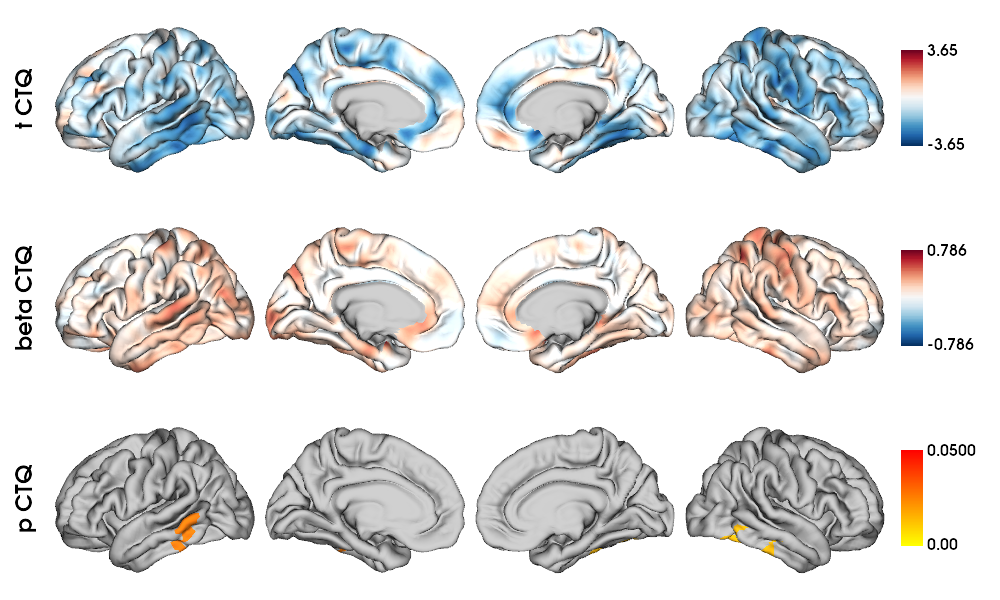

In [88]:
_, ctq, _, ctqint = ctq_sdi_effect(mt1_data, 'mt_m1')
ctqint

## Medication

In [89]:
demo_meds = pd.read_csv(f'{opth}/demodata_meds.csv')

demo_meds['Any'] = np.array(demo_meds['Medication1_type'].values != '9999')
demo_meds['Any'].replace({True: 'yes', False: 'no'}, inplace = True)

demo_meds['ID_new'] = demo_meds['ID'].str.extract(r'(\d+)').astype(int)

In [90]:
def contr_meds_slm(allsubjects_data, data_name, demo_meds = demo_meds):
    """
    Tests
    1. Group differences BPD vs CRC while controlling for medicaiton status
    2. Group meds interaction
    3. Influence of meds only
    """
    demo_m = demo_meds[demo_meds['Referral_Diagnosis'].isin([1,3])].copy()
    demo_m['Referral_Diagnosis'].replace({1:'BPD', 3:'CRC'}, inplace = True)
    demo_m['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    allsubjects_data_f = allsubjects_data[allsubjects_data['0'].isin(demo_m['ID_new'])].copy()
    
    term_age = FixedEffect(demo_m.Age)
    term_sex = FixedEffect(demo_m.Gender) # note: gender ~ sex in data collection
    term_group = FixedEffect(demo_m.Referral_Diagnosis)
    term_meds = FixedEffect(demo_m.Any)
    term_medtype = FixedEffect(demo_m.Medication1_type)
    
    contrast_group = (demo_m.Referral_Diagnosis == 'BPD').astype(int) - (demo_m.Referral_Diagnosis == 'CRC').astype(int)
    contrast_meds_any = demo_m.Any
    contrast_meds = demo_m.Medication1_type

    # first test = group differences controlling for medication
    model_groupdiff = term_age + term_sex + term_group + term_meds

    slm_groupdiff = SLM(model_groupdiff, contrast_group, surf = 'fsaverage5', mask = parc!=0, 
                        correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_groupdiff.fit(np.array(allsubjects_data_f)[:, 2:])

    p_groupdiff = slm_groupdiff.P['pval']['C']
    print(np.unique(p_groupdiff)) # sanity check
    p_groupdiff[(parc == 0) | (p_groupdiff>0.05)] = np.nan

    bpd_idx = model_groupdiff.matrix.columns.get_loc('Referral_Diagnosis_BPD') 
    crc_idx = model_groupdiff.matrix.columns.get_loc('Referral_Diagnosis_CRC') 
    beta = np.array(slm_groupdiff.coef)[bpd_idx, :] - np.array(slm_groupdiff.coef)[crc_idx, :]

    array_plot_groupdiff = np.vstack((slm_groupdiff.t, beta, p_groupdiff))
    plot_groupdiff = plot_hemispheres(surf_lh, surf_rh, array_plot_groupdiff, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t group', 'b group', 'p group'])

    with open(f"{opth}/robustness/{data_name}_groupdiff_contrmeds{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_groupdiff.data)

    pd.DataFrame({'t': np.array(slm_groupdiff.t)[0], 
                  'b': beta,
                  'p': np.array(slm_groupdiff.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_groupdiff_contrmeds_{data_name}_{'_sm5' if smooth else ''}.csv")

    # second test test = group differences interaction for medication
    model_interaction = term_age + term_sex + term_group * term_meds 
    contrast_interaction = (((demo_m.Referral_Diagnosis == 'BPD').astype(int) - 
                            (demo_m.Referral_Diagnosis == 'CRC').astype(int)) * 
                            ((demo_m.Any == 'yes').astype(int) -
                             (demo_m.Any == 'no').astype(int)))

    slm_interaction = SLM(model_interaction, contrast_interaction, surf = 'fsaverage5', mask = parc!=0, 
                        correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_interaction.fit(np.array(allsubjects_data_f)[:, 2:])

    p_interaction = slm_interaction.P['pval']['C']
    print(np.unique(p_interaction)) # sanity check
    p_interaction[(parc == 0) | (p_interaction>0.05)] = np.nan

    # crossed out because of imbalance of medication between datasets hence statistical nonsense
    #coef = np.array(slm_interaction.coef)
    #print(model_interaction.matrix.columns)
    #bpd_medyes_idx = model_interaction.matrix.columns.get_loc('Referral_Diagnosis_BPD*Any_yes')
    #bpd_medno_idx = model_interaction.matrix.columns.get_loc('Referral_Diagnosis_BPD*Any_no')
    #crc_medyes_idx = model_interaction.matrix.columns.get_loc('Referral_Diagnosis_CRC*Any_yes')
    #crc_medno_idx = model_interaction.matrix.columns.get_loc('Referral_Diagnosis_CRC*Any_no')

    #beta_interact = (coef[bpd_medyes_idx, :] - coef[bpd_medno_idx, :]) - (coef[crc_medyes_idx, :] - coef[crc_medno_idx, :])
    beta_interact = np.zeros(20484)
    
    array_plot_interaction = np.vstack((slm_interaction.t, beta_interact, p_interaction))
    plot_interact = plot_hemispheres(surf_lh, surf_rh, array_plot_groupdiff, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t inter', 'b inter', 'p inter'])

    with open(f"{opth}/robustness/{data_name}_groupmedsinteract{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_interact.data)

    pd.DataFrame({'t': np.array(slm_interaction.t)[0], 
                  'b': beta_interact,
                  'p': np.array(slm_interaction.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_groupmedsinteract_{data_name}_{'_sm5' if smooth else ''}.csv")

    # third test only influence of any meds
    term_mage = FixedEffect(demo_meds.Age)
    term_msex = FixedEffect(demo_meds.Gender) # note: gender ~ sex in data collection
    term_mmeds = FixedEffect(demo_meds.Any)
    
    model_meds = term_mage + term_msex + term_mmeds
    contrast_meds = (demo_meds.Any == 'yes').astype(int) - (demo_meds.Any == 'no').astype(int)
    
    slm_meds = SLM(model_meds, contrast_meds, surf = 'fsaverage5', mask = parc!=0, 
                        correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_meds.fit(np.array(allsubjects_data)[:, 2:])

    p_meds = slm_meds.P['pval']['C']
    print(np.unique(p_meds)) # sanity check
    p_meds[(parc == 0) | (p_meds>0.05)] = np.nan

    medsyes_idx = model_meds.matrix.columns.get_loc('Any_yes') 
    medsno_idx = model_meds.matrix.columns.get_loc('Any_no') 
    beta_meds = np.array(slm_meds.coef)[medsyes_idx, :] - np.array(slm_meds.coef)[medsno_idx, :]

    array_plot_meds = np.vstack((slm_meds.t, beta_meds, p_meds))
    plot_meds = plot_hemispheres(surf_lh, surf_rh, array_plot_meds, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t meds', 'b meds', 'p meds'])

    with open(f"{opth}/robustness/{data_name}_meds{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_meds.data)

    pd.DataFrame({'t': np.array(slm_meds.t)[0], 
                  'b': beta_meds,
                  'p': np.array(slm_meds.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_meds_{data_name}_{'_sm5' if smooth else ''}.csv")

    return plot_groupdiff, plot_interact, plot_meds

[1.]
[2.42541893e-06 2.42541902e-06 1.00000000e+00]
2026-08-12 16:26:06,135 - brainstat - WARNING - Column 0 has 2 unique values but was supplied as a numeric (i.e. continuous) variable. Should it be a categorical variable? If yes, the easiest way to provide categorical variables is to convert numerics to strings.
[1.]


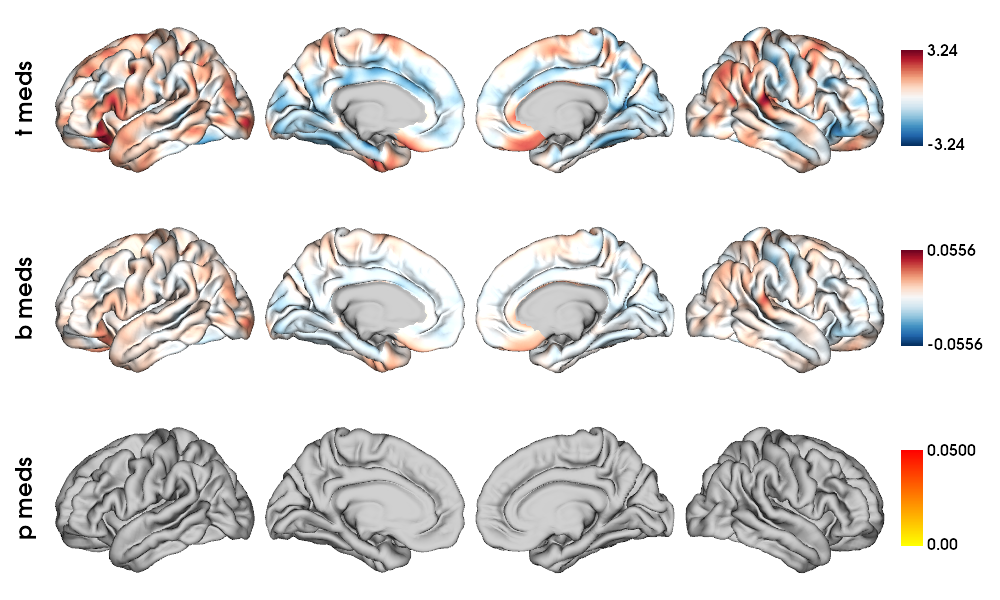

In [95]:
contr_meds_slm(mt1_data, 'mt_m1', demo_meds = demo_meds)[2]

## HiTOP spectra

In [96]:
demo_hitop = pd.read_csv(f'{opth}/demodata_hitop.csv')

In [97]:
def hitop_spectrum_slm(allsubjects_data, name, data_name):
    """
    Tests HiTOP spectrum influences
    define as function to easier run on different data
    name = one of INT_HiTOP, THO_HiTOP, DET_HiTOP, ANT_HiTOP, DIS_HiTOP
    """
    demo_hitop['Gender'].replace({1:'M', 2:'F'}, inplace = True)
    
    term_age = FixedEffect(demo_hitop.Age)
    term_sex = FixedEffect(demo_hitop.Gender) # note: gender ~ sex in data collection
    term_HiTOP = FixedEffect(demo_hitop[name])
    
    contrast_HiTOP = demo_hitop[name]
    contrast_age = demo_hitop.Age
    
    model = term_age + term_sex + term_HiTOP

    slm_p = SLM(model, contrast_HiTOP, surf = 'fsaverage5', mask = parc!=0, correction = ['fdr', 'rft'], cluster_threshold = 0.01)
    slm_p.fit(np.array(allsubjects_data)[:, 2:])

    p_p = slm_p.P['pval']['C']
    print(np.unique(p_p)) # sanity check
    p_p[(parc == 0) | (p_p>0.05)] = np.nan

    array_plot_p = np.vstack((slm_p.t, slm_p.coef[4], p_p))
    plot_p = plot_hemispheres(surf_lh, surf_rh, array_plot_p, embed_nb = True, size = (1000,600), zoom = 1.3, 
                 color_range  = ['sym', 'sym', (0, 0.05)], cmap = ['RdBu_r', 'RdBu_r', 'autumn_r'], color_bar = True, 
                 nan_color = (.7, .7, .7, 1), label_text =['t group', 'b group', 'p group'])

    with open(f"{opth}/{name}_{data_name}_test{'_sm5' if smooth else ''}.png", 'wb') as f:
        f.write(plot_p.data)

    pd.DataFrame({'t': np.array(slm_p.t)[0], 
                  'b': np.array(slm_p.coef)[4,:],
                  'p': np.array(slm_p.P['pval']['C'])}
                ).to_csv(f"{opth}/results/stats_{name}_{data_name}_{'_sm5' if smooth else ''}.csv")

    return slm_p, plot_p

In [98]:
ns = ['mt_m1', 'mt_m3', 'r2_m1', 'r2_m3']
for s in ['DIS_HiTOP', 'INT_HiTOP', 'ANT_HiTOP', 'THO_HiTOP', 'DET_HiTOP']:
    for d, data in enumerate([mt1_data, mt3_data, r2s1_data, r2s3_data]):
        print(s, ns[d])
        hitop_spectrum_slm(data, s, ns[d])

DIS_HiTOP mt_m1
[0.52167562 1.        ]
DIS_HiTOP mt_m3
[1.]
DIS_HiTOP r2_m1
[1.]
DIS_HiTOP r2_m3
[0.15490086 1.        ]
INT_HiTOP mt_m1
[0.91466357 1.        ]
INT_HiTOP mt_m3
[0.88746618 1.        ]
INT_HiTOP r2_m1
[0.78879662 1.        ]
INT_HiTOP r2_m3
[0.19922152 0.29909738 1.        ]
ANT_HiTOP mt_m1
[1.]
ANT_HiTOP mt_m3
[0.60500167 1.        ]
ANT_HiTOP r2_m1
[1.]
ANT_HiTOP r2_m3
[0.59389173 0.65537358 1.        ]
THO_HiTOP mt_m1
[1.]
THO_HiTOP mt_m3
[0.91387221 0.98900676 1.        ]
THO_HiTOP r2_m1
[0.59120975 1.        ]
THO_HiTOP r2_m3
[0.11488953 0.29885564 1.        ]
DET_HiTOP mt_m1
[1.]
DET_HiTOP mt_m3
[0.98658754 1.        ]
DET_HiTOP r2_m1
[0.99814693 1.        ]
DET_HiTOP r2_m3
[1.]


In [ ]:
yeo7 = fetch_parcellation(template = 'fsaverage5', atlas = 'yeo', n_regions = 7)
yeo7_400 = reduce_by_labels(yeo7, parc, red_op = 'mode')
yeo7names, yeo7colors = fetch_yeo_networks_metadata(7)

NameError: name 'fetch_parcellation' is not defined

In [100]:
# plot correlation of p-factor beta to HiTOP spectra
def plot_p_vs_spectra(name):
    p_b = pd.read_csv(f"{opth}/results/stats_p_HiTOP_{name}{'_sm5' if smooth else ''}.csv")['b'].values
    ant_b = pd.read_csv(f"{opth}/results/stats_ANT_HiTOP_{name}_{'_sm5' if smooth else ''}.csv")['b'].values
    int_b = pd.read_csv(f"{opth}/results/stats_INT_HiTOP_{name}_{'_sm5' if smooth else ''}.csv")['b'].values
    tho_b = pd.read_csv(f"{opth}/results/stats_THO_HiTOP_{name}_{'_sm5' if smooth else ''}.csv")['b'].values
    dis_b = pd.read_csv(f"{opth}/results/stats_DIS_HiTOP_{name}_{'_sm5' if smooth else ''}.csv")['b'].values
    det_b = pd.read_csv(f"{opth}/results/stats_DET_HiTOP_{name}_{'_sm5' if smooth else ''}.csv")['b'].values

    p_b400 = reduce_by_labels(p_b, parc)[1:]
    ant_b400 = reduce_by_labels(ant_b, parc)[1:]
    int_b400 = reduce_by_labels(int_b, parc)[1:]
    tho_b400 = reduce_by_labels(tho_b, parc)[1:]
    dis_b400 = reduce_by_labels(dis_b, parc)[1:]
    det_b400 = reduce_by_labels(det_b, parc)[1:]

    sbn.set_style('white')
    fig, ax = plt.subplots(1,5, figsize = (10,2), sharey = True)
    sbn.regplot(x = p_b400, y = ant_b400, ax = ax[0], 
               line_kws = dict({'color': 'black'}), scatter = False)
    sbn.scatterplot(x = p_b400, y = ant_b400, hue = yeo7_400[1:], ax = ax[0], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
    ax[0].set_title('ANT')
    sbn.regplot(x = p_b400, y = int_b400, ax = ax[1], 
               line_kws = dict({'color': 'black'}), scatter= False)
    sbn.scatterplot(x = p_b400, y = int_b400, hue = yeo7_400[1:], ax = ax[1], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
    ax[1].set_title('INT')
    sbn.regplot(x = p_b400, y = tho_b400, ax = ax[2], 
               line_kws = dict({'color': 'black'}), scatter = False)
    sbn.scatterplot(x = p_b400, y = tho_b400, hue = yeo7_400[1:], ax = ax[2], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
    ax[2].set_title('THO')
    sbn.regplot(x = p_b400, y = det_b400, ax = ax[3], 
               line_kws = dict({'color': 'black'}), scatter = False)
    sbn.scatterplot(x = p_b400, y = det_b400, hue = yeo7_400[1:], ax = ax[3], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
    ax[3].set_title('DET')
    sbn.regplot(x = p_b400, y = dis_b400, ax = ax[4],  
               line_kws = dict({'color': 'black'}), scatter = False)
    sbn.scatterplot(x = p_b400, y = dis_b400, hue = yeo7_400[1:], ax = ax[4], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
    ax[4].set_title('DIS')
    fig.savefig(f"{opth}/figs/HiTOP_scatter_{name}.svg")

/tmp/ipykernel_317461/189701740.py:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sbn.scatterplot(x = p_b400, y = ant_b400, hue = yeo7_400[1:], ax = ax[0], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
/tmp/ipykernel_317461/189701740.py:25: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sbn.scatterplot(x = p_b400, y = int_b400, hue = yeo7_400[1:], ax = ax[1], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
/tmp/ipykernel_317461/189701740.py:29: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sbn.scatterplot(x = p_b400, y = tho_b400, hue = yeo7_400[1:], ax = ax[2], s= 15, palette = yeo7colors, legend = False, alpha = 0.8)
/tmp/ipykernel_317461/189701740.py:33: UserWarning: Numpy array is 

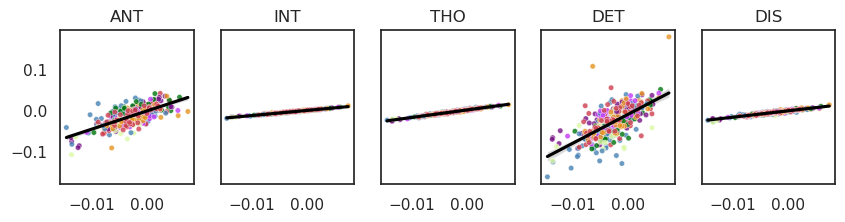

In [104]:
plot_p_vs_spectra('mt_m1')

# Helpers

In [1]:
# overview
for analysis in ['group', 'age', 'ctq', 'sdi']:
    for metric in ['mt_m1', 'mt_m2', 'mt_m3', 'r2_m1', 'r2_m2', 'r2_m3']:
        b_one = pd.read_csv(f'{opth}/results/stats_{analysis}_{metric}_sm5.csv')['p']
        print(analysis, metric, np.unique(b_one.values, return_counts = True))
print('---depths---')
for analysis in ['group', 'age', 'ctq', 'sdi']:
    for d in range(1,13):
        b_one = pd.read_csv(f'{opth}/results/stats_{analysis}_mt_d{d}.csv')['p']
        print(analysis, f'mt d{d}', np.unique(b_one.values, return_counts = True))
        b_one = pd.read_csv(f'{opth}/results/stats_{analysis}_r2_d{d}.csv')['p']
        print(analysis, f'r2 d{d}', np.unique(b_one.values, return_counts = True))

NameError: name 'pd' is not defined

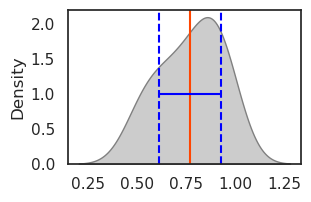

In [51]:
df_one = pd.read_csv(f'{pth}/247_mtatdepths.csv')

sbn.set_style('white')
fig, ax = plt.subplots(figsize = (3,2))
sbn.kdeplot(df_one.loc[10].values[1:13], fill = True, color = 'grey', alpha = 0.4)
mean_example = np.mean(df_one.loc[10].values[1:13])
std_example = np.std(df_one.loc[10].values[1:13], ddof = 1)
ax.axvline(x = mean_example, color = 'orangered')
ax.axvline(x = mean_example-std_example, color = 'blue', ls = '--')
ax.axvline(x = mean_example+std_example, color = 'blue', ls = '--')
ax.hlines(y = 1, xmin = mean_example-std_example, xmax = mean_example+std_example, color = 'blue')
fig.savefig(f'{opth}/exampledistribution_2.svg')

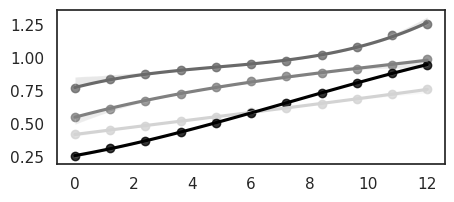

In [100]:
df_one = pd.read_csv(f'{pth}/247_mtatdepths.csv')

fig, ax = plt.subplots(figsize = (5,2))
sbn.regplot(x = np.linspace(0,12,11), y = df_one.loc[10].values[2:13], order = 3, color = 'grey')
sbn.regplot(x = np.linspace(0,12,11), y = df_one.loc[1500].values[2:13], order = 3, color = 'lightgrey')
sbn.regplot(x = np.linspace(0,12,11), y = df_one.loc[100].values[2:13], order = 3, color = 'black')
sbn.regplot(x = np.linspace(0,12,11), y = df_one.loc[15000].values[2:13], order = 3, color = 'dimgrey')
fig.savefig(f'{opth}/figs/exampleprofile.svg')